# Functional API

En este notebook vamos a usar la API funcional para crear un modelo de red neuronal.

### SETUP

In [1]:
!pip install -q tensorflow
!pip install -q numpy

In [2]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow-datasets')

import tensorflow as tf 
from tensorflow.keras.models import Model 
from tensorflow.keras.layers import Input, Dense, concatenate
from tensorflow.keras.datasets import mnist

import numpy as np
import matplotlib.pyplot as plt

2026-05-14 20:45:11.474592: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 20:45:11.475365: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 20:45:11.477747: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 20:45:11.484167: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-14 20:45:11.497371: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

## Dataset

Vamos a utilizar el dataset MNIST para tomar 2 imágenes y determinar si se tratan del mísmo dígito, en ese caso la variable `label` tomará el valor 1, cc tomará valor 0.

El dataset en sí no viene preparado para esta tarea, sin embargo podemos armar secuencias de pares con dígitos iguales y distintos para alimentar a nuestro modelo.

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Pixel value normalization
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# Flattening image (shape is 28x28 so resut is 784 )
x_train = x_train.reshape(-1, 784)
x_test  = x_test.reshape(-1, 784)

def make_pairs(x, y, num_pairs):
    pairs_A, pairs_B, labels = [], [], []
    
    class_indices = [np.where(y == i)[0] for i in range(10)]
    
    for _ in range(num_pairs):
        
        # Same digits => label=1
        digit = np.random.randint(0, 10)
        idx1, idx2 = np.random.choice(class_indices[digit], 2, replace=False)
        pairs_A.append(x[idx1])
        pairs_B.append(x[idx2])
        labels.append(1)
        
        # Different digits => label=0
        digit1, digit2 = np.random.choice(10, 2, replace=False)
        idx1 = np.random.choice(class_indices[digit1])
        idx2 = np.random.choice(class_indices[digit2])
        pairs_A.append(x[idx1])
        pairs_B.append(x[idx2])
        labels.append(0)
    
    return np.array(pairs_A), np.array(pairs_B), np.array(labels)

# Create pairs
train_A, train_B, train_labels = make_pairs(x_train, y_train, num_pairs=30000)
test_A,  test_B,  test_labels  = make_pairs(x_test,  y_test,  num_pairs=5000)

## Modelo

Armemos un modelo más sofisticado que lo que veníamos haciendo anteriormente, en particular sigamos el siguiente esquema:

```mermaid
flowchart LR
    A((Input Layer A)) --> HA((Hidden Layer 1A))
    A --> HA
    A --> HA
    B((Input Layer B)) --> HB((Hidden Layer 1B))
    B --> HB
    B --> HB
    HA --> HC(Input Concatenation)   
    HB --> HC
    HC -->D((Dropout Layer)) 
    D -->HF((Hidden Layer))
    D --> HF
    D --> HF
    HF --> O((Output Layer))
    HF --> O
    HF --> O
```

En este sentido lo que hacemos es armar dos "submodelos" (ramas de procesamiento), luego sus outputs son combinados y se pasan por una capa de Dropout que desactiva neuronas al azar para impedir la dependencia de neuronas específicas (consecuentemente ayuda a prevenir overfitting y mejorar robustez) utilizan para el output. 

In [4]:
input_layerA = Input(shape=(784,), name="Input_Layer_A")
input_layerB = Input(shape=(784,), name="Input_Layer_B")

hidden_layerA = Dense(64, activation="relu")(input_layerA)
hidden_layerB = Dense(64, activation="relu")(input_layerB)

branchA = Model(inputs=input_layerA, outputs=hidden_layerA)
branchB = Model(inputs=input_layerB, outputs=hidden_layerB)

concatenation = concatenate([branchA.output, branchB.output])

activation_layer = Dense(128, activation="relu")(concatenation)
output_layer = Dense(1, activation='sigmoid')(activation_layer) 

model = Model(inputs=[input_layerA, input_layerB], outputs=output_layer)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=["accuracy"])

## Entrenamiento 

Teniendo el modelo armado podemos pasar al entrenamiento usando nuestros dos inputs

In [5]:
history = model.fit(x={"Input_Layer_A": train_A, "Input_Layer_B": train_B}, y=train_labels, epochs=20, batch_size=64) 

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8377 - loss: 0.3573
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9265 - loss: 0.1888
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9503 - loss: 0.1333
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9632 - loss: 0.1000
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9726 - loss: 0.0774
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9788 - loss: 0.0606
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9837 - loss: 0.0470
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9865 - loss: 0.0383
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9897 - loss: 0.0297
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9913 - loss: 0.0251
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9927 - loss: 0.0209
Epoch 12/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

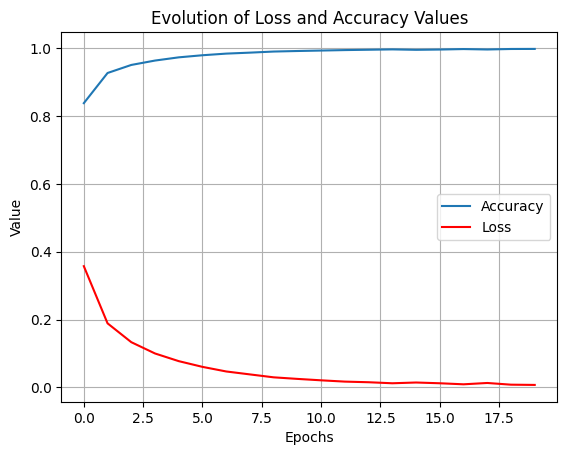

In [15]:
model_accuracy_history = history.history["accuracy"]
model_loss_history = history.history["loss"] 

epochs = np.arange(20)

fig, ax = plt.subplots()

ax.plot(epochs, model_accuracy_history, label="Accuracy")
ax.plot(epochs, model_loss_history, color="red", label="Loss")
plt.title("Evolution of Loss and Accuracy Values")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.grid()
plt.legend()
plt.show()

Si bien podemos ver que nuestro modelo es bueno y su tendencia de valores es lógico quizás _sospechosamente_ bueno y podría indicar un overfitting del dataset, sin embargo esto podemos comprobarlo con el testing split.

In [ ]:
loss, accuracy = model.evaluate({"Input_Layer_A":test_A,"Input_Layer_B":test_B}, test_labels) 
print(f'Test loss: {loss}') 
print(f'Test accuracy: {accuracy}') 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9553 - loss: 0.1662
Test loss: 0.16620703041553497
Test accuracy: 0.955299973487854


Resulta que nuestro modelo tuvo un buen rendimiento con el split de testeo y por lo tanto concluimos que armamos una red neuronal efectiva, no solo por su precisión sino que además es un modelo relativamente sencillo y con tiempos de ejecución cortos.